In [27]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import AllChem, DataStructs
import numpy as np
from catboost import CatBoostRegressor
from hyperopt import hp, tpe, Trials, STATUS_OK, fmin
from hyperopt.early_stop import no_progress_loss
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings("ignore")
from flaml import AutoML
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import shap
from tqdm import tqdm
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, 
    AdaBoostRegressor, BaggingRegressor, GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import (
    Lasso, LassoLars, LinearRegression, Ridge,
    SGDRegressor, PassiveAggressiveRegressor, ElasticNet, HuberRegressor,
    BayesianRidge, OrthogonalMatchingPursuit
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import NuSVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

In [28]:
train=pd.read_csv('/home/ychen3338/project_2/data/vis_train.csv')
test=pd.read_csv('/home/ychen3338/project_2/data/vis_test.csv')

In [29]:
class morgan_fp:
    def __init__(self, radius, length):
        self.radius = radius
        self.length = length
    def __call__(self, smiles):
        mol = Chem.MolFromSmiles(smiles)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, self.radius, self.length)
        npfp = np.array(list(fp.ToBitString())).astype('float32')
        return npfp

In [30]:
def conv_data(data, fp):
    data['c-fp'] = data['Cation'].apply(fp)
    x_c=np.array(list(data['c-fp']))
    data['a-fp'] = data['Anion'].apply(fp)
    x_a=np.array(list(data['a-fp']))
    x_con = data[['T', 'P']].values
    xx = np.concatenate([x_c, x_a, x_con], axis =1)
    y = data['vis'].values
    return xx, y

In [31]:
result = pd.read_csv('/home/ychen3338/project_2/code/vis/vis_MF.csv')
result.sort_values('loss', ascending= True, inplace = True)
result.reset_index(drop = True, inplace =True)
result.head()

,loss,train_loss,params,iteration
0,0.417170,0.370807,"{'bagging_temperature': 52.25329510822344, 'de...",796
1,0.425408,0.381786,"{'bagging_temperature': 17.82211813098283, 'de...",788
2,0.426642,0.379143,"{'bagging_temperature': 97.29168934774427, 'de...",953
3,0.427767,0.384241,"{'bagging_temperature': 69.05902993113473, 'de...",801
4,0.429827,0.384827,"{'bagging_temperature': 74.73649439431381, 'de...",804


In [32]:
import ast
params = result.loc[0, 'params']
params = ast.literal_eval(params)

In [33]:
params

{'bagging_temperature': 52.25329510822344,
 'depth': 6,
 'fp_length': 1199,
 'fp_radius': 4,
 'iterations': 981,
 'l2_leaf_reg': 3.295977431281289,
 'learning_rate': 0.024757076222361063,
 'random_strength': 1.1122601480662953}

In [ ]:
# params ={'bagging_temperature': 176.17415369430844, 'depth': 6, 
#  'fp_length': 4715, 'fp_radius': 2, 
#  'iterations': 998, 'l2_leaf_reg': 3.0738850907833077, 
#  'learning_rate': 0.024818144275044182, 
#  'random_strength': 1.2607685392249053}

{'bagging_temperature': 176.17415369430844, 'depth': 6, 'fp_length': 4715, 'fp_radius': 2, 'iterations': 998, 'l2_leaf_reg': 3.0738850907833077, 'learning_rate': 0.024818144275044182, 'random_strength': 1.2607685392249053}

In [34]:
SEED = 42
models = [
    ('CatBoost', CatBoostRegressor(depth = params['depth'], l2_leaf_reg= params['l2_leaf_reg'], learning_rate = params['learning_rate'],
                         iterations=params['iterations'], bagging_temperature=params['bagging_temperature'],
                         random_strength=params['random_strength'],random_state=10, verbose=False)),
    ('XGBoost',  XGBRegressor(random_state=SEED)),
    ('LightGBM', LGBMRegressor(random_state=SEED)),
    ('RandomForest', RandomForestRegressor(random_state=SEED)),
    ('ExtraTrees',  ExtraTreesRegressor(random_state=SEED)),
    ('GradientBoosting', GradientBoostingRegressor(random_state=SEED)),
    ('HistGradientBoosting', HistGradientBoostingRegressor(random_state=SEED)),
    ('DecisionTree', DecisionTreeRegressor(random_state=SEED)),

    ('SVM', make_pipeline(StandardScaler(), SVR())),
    ('NuSVM', make_pipeline(StandardScaler(), NuSVR())),
    ('MLP', make_pipeline(StandardScaler(), MLPRegressor(max_iter=1000, random_state=SEED))),

    ('Lasso', make_pipeline(StandardScaler(), Lasso(random_state=SEED))),
    ('Ridge', make_pipeline(StandardScaler(), Ridge(random_state=SEED))),
    ('ElasticNet', make_pipeline(StandardScaler(), ElasticNet(random_state=SEED))),
    ('LassoLars', LassoLars()),                       
    ('LinearRegression', LinearRegression()),          
    ('SGDRegressor', SGDRegressor(random_state=SEED)),
    ('BayesianRidge', BayesianRidge()),
    ('OrthogonalMatching', OrthogonalMatchingPursuit()),

    ('AdaBoost', AdaBoostRegressor(random_state=SEED)),
    ('Bagging',  BaggingRegressor(random_state=SEED)),

    ('HuberRegressor', HuberRegressor()),
    ('PassiveAggressive', PassiveAggressiveRegressor(random_state=SEED)),
    ('KNN', KNeighborsRegressor())                     
]
fp = morgan_fp(params['fp_radius'], params['fp_length'])
X_train, y_train = conv_data(train, fp)
X_test, y_test = conv_data(test, fp)

results = []

for name, model in models:
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = r2_score(y_test, y_pred)
        results.append((name, score))
    except Exception as e:
        print(f"{name} Error: {str(e)}")

sorted_results = sorted(results, key=lambda x: x[1], reverse=True)

print("Algorithm R² Ranking:")
for idx, (name, score) in enumerate(sorted_results, 1):
    print(f"{idx}. {name}: {score:.4f}")

Algorithm R² Ranking:
1. ExtraTrees: 0.9726
2. XGBoost: 0.9645
3. MLP: 0.9618
4. RandomForest: 0.9512
5. HistGradientBoosting: 0.9481
6. LightGBM: 0.9480
7. Bagging: 0.9453
8. CatBoost: 0.9409
9. DecisionTree: 0.9047
10. Ridge: 0.8974
11. BayesianRidge: 0.8967
12. OrthogonalMatching: 0.8836
13. GradientBoosting: 0.8275
14. SVM: 0.8080
15. NuSVM: 0.8054
16. KNN: 0.7468
17. HuberRegressor: 0.5091
18. AdaBoost: 0.4791
19. PassiveAggressive: 0.4151
20. LassoLars: 0.3338
21. ElasticNet: 0.1662
22. Lasso: -0.0001
23. LinearRegression: -3826896766.4887
24. SGDRegressor: -785347500706615948533874349511278592.0000


In [9]:
fp = morgan_fp(params['fp_radius'], params['fp_length'])

automl = AutoML(random_state=42)
n_jobs = 16
time_budget = 1200 # in seconds


In [10]:
automl_settings = {
    "time_budget": time_budget,
    "metric": 'mse',
    "task": 'regression',
    "eval_method": "cv",
    "n_splits": 5,
    "estimator_list": [
        'xgboost', 
        'xgb_limitdepth', 
        'rf', 
        # 'lrl1', 
        'catboost', 
        'extra_tree', 
        'histgb',
        'kneighbor', 
        'sgd', 
        'enet', 
        'lassolars', 
        'lgbm',
    ],
    "n_jobs": n_jobs,  
    "log_file_name": '/home/ychen3338/project_2/code/tox/AutoML_emulator.log',  

}

X, y = conv_data(train, fp)
automl.fit(X_train=X, y_train=y, **automl_settings)
print("Best estimator:", automl.model.estimator)

[flaml.automl.logger: 07-14 23:02:52] {1728} INFO - task = regression
[flaml.automl.logger: 07-14 23:02:52] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 07-14 23:02:52] {1838} INFO - Minimizing error metric: mse
[flaml.automl.logger: 07-14 23:02:52] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'catboost', 'extra_tree', 'histgb', 'kneighbor', 'sgd', 'enet', 'lassolars', 'lgbm']
[flaml.automl.logger: 07-14 23:02:52] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 07-14 23:02:53] {2393} INFO - Estimated sufficient time budget=7247s. Estimated necessary time budget=54s.
[flaml.automl.logger: 07-14 23:02:53] {2442} INFO -  at 0.7s,	estimator xgboost's best error=2.1650,	best estimator xgboost's best error=2.1650
[flaml.automl.logger: 07-14 23:02:53] {2258} INFO - iteration 1, current learner histgb
[flaml.automl.logger: 07-14 23:03:06] {2442} INFO -  at 13.8s,	estimator histgb's best error=2.1637,	best estimator h

Best estimator: XGBRegressor(base_score=None, booster=None, callbacks=[],
             colsample_bylevel=0.44128663641659543, colsample_bynode=None,
             colsample_bytree=0.6329601683909993, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None,
             grow_policy='lossguide', importance_type=None,
             interaction_constraints=None, learning_rate=0.0830920864858575,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=0, max_leaves=11,
             min_child_weight=1.6925169932467672, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=298,
             n_jobs=16, num_parallel_tree=None, random_state=None, ...)

In [11]:
best_model = automl.model.estimator
joblib.dump(best_model, 'best_lgbm_model.pkl')

['best_lgbm_model.pkl']

In [12]:
best_model = joblib.load('/home/ychen3338/project_2/code/vis/best_lgbm_model.pkl')

In [13]:
X_train, y_train = conv_data(train, fp)
X_test, y_test = conv_data(test, fp)

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

In [14]:
print("Train R2: {:.4f}, MSE: {:.4f}".format(r2_score(y_train, y_train_pred), mean_squared_error(y_train, y_train_pred)))
print("Test  R2: {:.4f}, MSE: {:.4f}".format(r2_score(y_test, y_test_pred), mean_squared_error(y_test, y_test_pred)))

Train R2: 0.9927, MSE: 0.0195
Test  R2: 0.9833, MSE: 0.0437


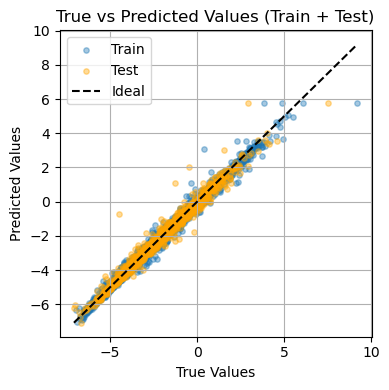

In [15]:
plt.figure(figsize=(4,4))

plt.scatter(y_train, y_train_pred, label='Train', alpha=0.4, s=15)
plt.scatter(y_test, y_test_pred, label='Test', alpha=0.4, s=15, color='orange')

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs Predicted Values (Train + Test)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

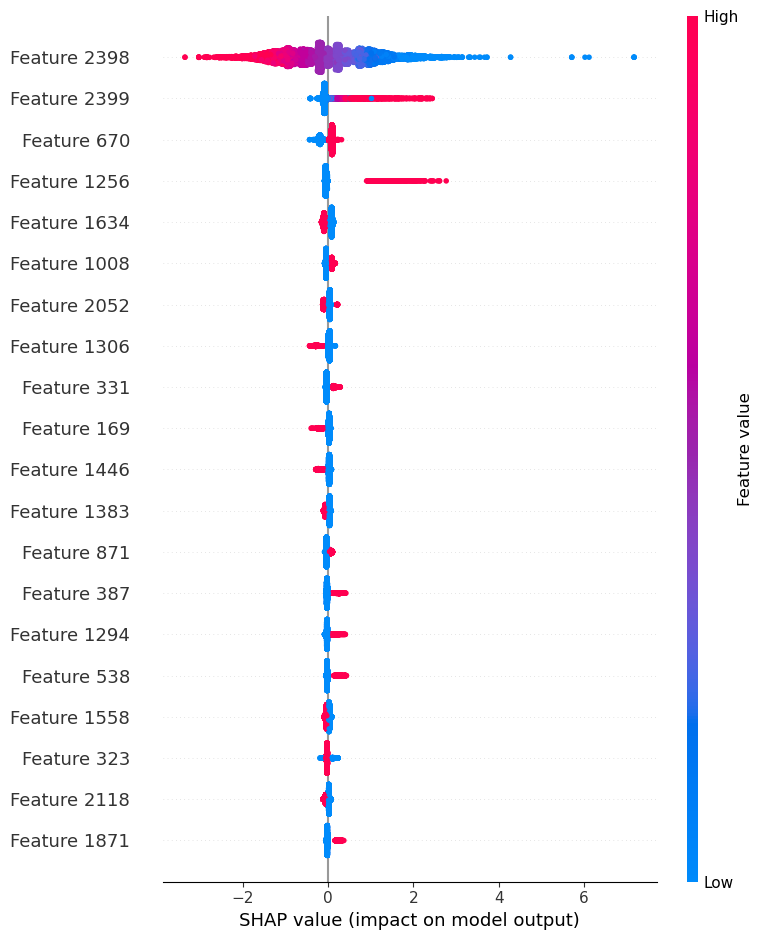

In [16]:
explainer = shap.Explainer(best_model)
shap_values = explainer(X_train)

shap.summary_plot(shap_values, X_train, max_display=20, color_bar=True,show=False)
plt.show()

In [19]:
df = pd.read_csv('/home/ychen3338/project_2/data/vis_train.csv')
print(df['vis'].describe())

count    11281.000000
mean        -2.581907
std          1.632995
min         -6.938214
25%         -3.729701
50%         -2.798522
75%         -1.676647
max          9.210340
Name: vis, dtype: float64


In [20]:
# Convert SHAP values to a DataFrame
shap_values_df = pd.DataFrame(shap_values.values, columns=[f'Position_{i}' for i in range(X_train.shape[1])])

# Initialize a list to store mean SHAP values for positions where MF == 1
mean_shap_values = []

# Iterate over each position (feature) in the fingerprint
for i in range(X_train.shape[1]):
    # Filter SHAP values where the feature (fingerprint position) is set to 1
    shap_values_at_1 = shap_values_df[X_train[:, i] == 1][f'Position_{i}']

    # Calculate the mean SHAP value at this position when MF == 1
    mean_shap_value = shap_values_at_1.mean()
    mean_shap_values.append(mean_shap_value)

# Create a DataFrame to store the result
mean_shap_df = pd.DataFrame({
    'Position': range(len(mean_shap_values)),
    'Mean_SHAP_Value': mean_shap_values
})

print(mean_shap_df)

      Position  Mean_SHAP_Value
0            0         0.009698
1            1         0.156608
2            2         0.001214
3            3         0.000000
4            4         0.000000
...        ...              ...
2395      2395        -0.041803
2396      2396         0.000000
2397      2397              NaN
2398      2398              NaN
2399      2399              NaN

[2400 rows x 2 columns]


In [21]:
mean_shap_df.to_csv('/home/ychen3338/project_2/code/vis/shap_feature_vis.csv', index=False)

In [17]:
mean_shap_df= pd.read_csv('/home/ychen3338/project_2/code/vis/shap_feature_vis.csv')
print(mean_shap_df)

      Position  Mean_SHAP_Value
0            0         0.009698
1            1         0.156608
2            2         0.001214
3            3         0.000000
4            4         0.000000
...        ...              ...
2393      2393              NaN
2394      2394         0.009675
2395      2395        -0.041803
2396      2396         0.000000
2397      2397              NaN

[2398 rows x 2 columns]


In [18]:
SHAP_PATH = '/home/ychen3338/project_2/code/vis/shap_feature_vis.csv'
TRAIN_PATH = '/home/ychen3338/project_2/data/vis_train.csv'

shap_df = pd.read_csv(SHAP_PATH)
shap_values = shap_df['Mean_SHAP_Value'].values
nonzero_bits = ((~np.isnan(shap_values)) & (shap_values != 0)).astype(int)
negative_bits = ((~np.isnan(shap_values)) & (shap_values < 0)).astype(int)
n_bits = len(nonzero_bits)

nonzero_fp = DataStructs.ExplicitBitVect(n_bits)
negative_fp = DataStructs.ExplicitBitVect(n_bits)
for i in range(n_bits):
    if nonzero_bits[i]:
        nonzero_fp.SetBit(i)
    if negative_bits[i]:
        negative_fp.SetBit(i)

train_df = pd.read_csv(TRAIN_PATH)
train_smiles = train_df['SMILES'].tolist()
train_tms = train_df['vis'].tolist()



In [19]:
dice_scores = []
for smi in train_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=4, nBits=n_bits)
        dice = DataStructs.DiceSimilarity(fp, nonzero_fp)
        dice_scores.append(dice)

p25_dice = np.percentile(dice_scores, 25)
print(f"Step 1: 25th percentile of Dice similarity = {p25_dice:.3f}")

Step 1: 25th percentile of Dice similarity = 0.049


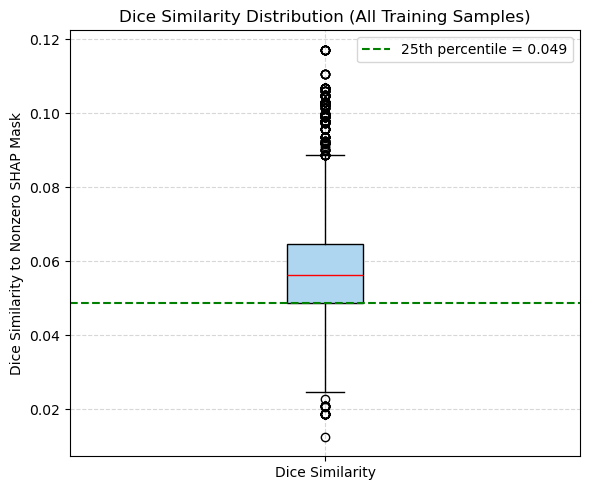

In [20]:
plt.figure(figsize=(6, 5))
plt.boxplot(dice_scores,
            labels=["Dice Similarity"],
            showfliers=True,
            patch_artist=True,
            boxprops=dict(facecolor="#AED6F1"),
            medianprops=dict(color="red"))

plt.axhline(y=p25_dice, color='green', linestyle='--', label=f"25th percentile = {p25_dice:.3f}")

plt.ylabel("Dice Similarity to Nonzero SHAP Mask")
plt.title("Dice Similarity Distribution (All Training Samples)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [21]:
tanimoto_scores_tm_low = []
for smi, vis in zip(train_smiles, train_tms):
    if vis >= np.log(10) :
        continue
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=4, nBits=n_bits)
        tanimoto = DataStructs.TanimotoSimilarity(fp, negative_fp)
        tanimoto_scores_tm_low.append(tanimoto)

tanimoto_scores_all = []
for smi in train_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=4, nBits=n_bits)
        tanimoto = DataStructs.TanimotoSimilarity(fp, negative_fp)
        tanimoto_scores_all.append(tanimoto)

pXX = np.percentile(tanimoto_scores_tm_low, 25)
print(f"Step 2: Tanimoto similarity of samples = {pXX:.3f}")

Step 2: Tanimoto similarity of samples = 0.023


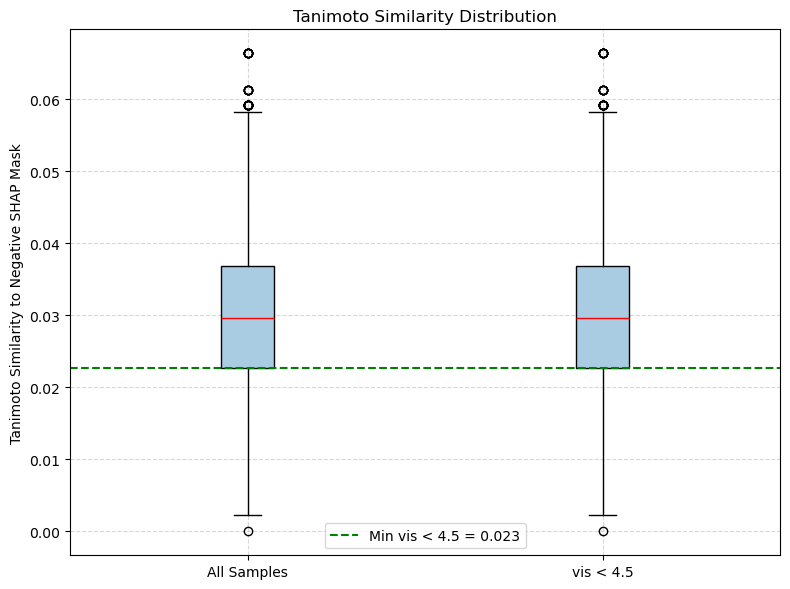

In [22]:
plt.figure(figsize=(8, 6))
plt.boxplot([tanimoto_scores_all, tanimoto_scores_tm_low],
            labels=["All Samples", "vis < 4.5"],
            showfliers=True,
            patch_artist=True,
            boxprops=dict(facecolor="#A9CCE3"),
            medianprops=dict(color="red"))

plt.axhline(y=pXX, color='green', linestyle='--', label=f"Min vis < 4.5 = {pXX:.3f}")
plt.ylabel("Tanimoto Similarity to Negative SHAP Mask")
plt.title("Tanimoto Similarity Distribution")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [23]:
df = pd.read_csv('/home/ychen3338/project_2/code/vis/simles_vis.csv')


In [24]:
len(df)

279688

In [25]:
df = pd.read_csv('/home/ychen3338/project_2/data/after_m_tox_vis.csv')

In [26]:
len(df)

243765